<a href="https://colab.research.google.com/github/Codersweta7/Codersweta7/blob/main/WAAM_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Import Libraries

We need 3 libraries:
- **numpy** → matrix math and normal equation
- **pandas** → read the CSV file
- **matplotlib** → plot graphs


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries loaded!")


All libraries loaded!


Uploading and Reading csv file


In [30]:
from google.colab import files

print("Click the button below to upload your waam.csv file...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print()
print(f"File loaded: {filename}")
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print()
print(df)


Click the button below to upload your waam.csv file...


Saving waam.csv to waam (2).csv

File loaded: waam (2).csv
Rows: 21   Columns: 5

    Current  Voltage  Travel Speed  Width  Height
0       100       17           400   3.79    3.01
1       140       17           400   4.03    3.98
2       100       23           400   5.08    2.49
3       140       23           400   5.41    3.46
4       100       20           300   4.96    3.29
5       140       20           300   5.42    4.22
6       100       20           500   4.19    2.02
7       140       20           500   4.53    3.14
8       120       17           300   4.31    4.21
9       120       23           300   6.02    3.66
10      120       17           500   3.81    3.12
11      120       23           500   5.21    2.62
12      120       20           400   4.97    3.17
13      120       20           400   5.00    3.28
14      120       20           400   4.97    3.30
15      120       20           400   4.87    3.22
16      120       20           400   5.01    3.20
17      110       

---
 Extract Inputs and Outputs from the File

We pull each column out of the DataFrame into NumPy arrays.




In [31]:
I_col = df['Current'].values        # Current (A)
U_col = df['Voltage'].values        # Voltage (V)
v_col = df['Travel Speed'].values   # Travel Speed (mm/min)
y_BW  = df['Width'].values          # Bead Width  (target)
y_BH  = df['Height'].values         # Bead Height (target)

n = len(df)   # number of experiments

print(f"Experiments loaded : {n}")
print(f"Current      range : {I_col.min()} to {I_col.max()} A")
print(f"Voltage      range : {U_col.min()} to {U_col.max()} V")
print(f"Travel Speed range : {v_col.min()} to {v_col.max()} mm/min")
print(f"Bead Width   range : {y_BW.min()} to {y_BW.max()} mm")
print(f"Bead Height  range : {y_BH.min()} to {y_BH.max()} mm")


Experiments loaded : 21
Current      range : 100 to 140 A
Voltage      range : 17 to 23 V
Travel Speed range : 300 to 500 mm/min
Bead Width   range : 3.79 to 6.02 mm
Bead Height  range : 2.02 to 4.22 mm


---
Build Feature Matrix X

Expand 3 inputs into 10 features:

$$X = [1,\ I,\ U,\ v,\ I^2,\ U^2,\ v^2,\ I{\cdot}U,\ I{\cdot}v,\ U{\cdot}v]$$

This gives a matrix of shape **(n rows × 10 columns)**.


In [32]:
X = np.column_stack([
    np.ones(n),       # 1      — constant / intercept
    I_col,            # I      — current
    U_col,            # U      — voltage
    v_col,            # v      — travel speed
    I_col**2,         # I²     — current squared
    U_col**2,         # U²     — voltage squared
    v_col**2,         # v²     — speed squared
    I_col * U_col,    # I×U    — current × voltage
    I_col * v_col,    # I×v    — current × speed
    U_col * v_col,    # U×v    — voltage × speed
])

print(f"Feature matrix X shape: {X.shape}")
print("Columns: [1,  I,  U,  v,  I²,  U²,  v²,  I·U,  I·v,  U·v]")


Feature matrix X shape: (21, 10)
Columns: [1,  I,  U,  v,  I²,  U²,  v²,  I·U,  I·v,  U·v]


---
Solve Normal Equation → Get Coefficients

$$\mathbf{c} = (X^T X)^{-1}\, X^T y$$

- `XtX` = $X^T X$ → 10×10 matrix (left-hand side)
- `Xty` = $X^T y$ → 10×1 vector  (right-hand side)
- `c`   = solution → 10 coefficients

Done separately for BW and BH.


In [33]:
XtX    = X.T @ X               # 10x10 matrix

Xty_BW = X.T @ y_BW           # right-hand side for BW
Xty_BH = X.T @ y_BH           # right-hand side for BH

c_BW = np.linalg.inv(XtX) @ Xty_BW    # 10 coefficients for BW
c_BH = np.linalg.inv(XtX) @ Xty_BH    # 10 coefficients for BH

names = ['Intercept','I','U','v','I²','U²','v²','I·U','I·v','U·v']

print("="*52)
print("  BW Equation Coefficients")
print("="*52)
for name, c in zip(names, c_BW):
    print(f"  {name:<12}  {c:+.8f}")

print()
print("="*52)
print("  BH Equation Coefficients")
print("="*52)
for name, c in zip(names, c_BH):
    print(f"  {name:<12}  {c:+.8f}")


  BW Equation Coefficients
  Intercept     -15.16238068
  I             +0.13843265
  U             +0.99180204
  v             -0.00055175
  I²            -0.00055906
  U²            -0.01796072
  v²            +0.00000295
  I·U           +0.00036011
  I·v           -0.00001007
  U·v           -0.00021455

  BH Equation Coefficients
  Intercept     +6.96136419
  I             +0.08642199
  U             -0.59470401
  v             -0.01212338
  I²            -0.00027371
  U²            +0.01315721
  v²            +0.00000517
  I·U           -0.00020288
  I·v           +0.00001952
  U·v           +0.00000411


In [34]:

#  COMPLETE EQUATIONS — actual numbers filled in from your data

names   = ['1 (intercept)', 'I', 'U', 'v', 'I²', 'U²', 'v²', 'I·U', 'I·v', 'U·v']
symbols = ['1',             'I', 'U', 'v', 'I²', 'U²', 'v²', 'I·U', 'I·v', 'U·v']
print("=" * 65)
print("  BEAD WIDTH (BW) — Full Equation")
print("=" * 65)
print()
bw_parts = []
for i, (name, sym, c) in enumerate(zip(names, symbols, c_BW)):
    sign = "+" if c >= 0 else "-"
    if i == 0:
        line = f"  BW  =  {c:+.6f}"
    else:
        line = f"         {sign} {abs(c):.8f}  ×  {sym}"
    bw_parts.append((sign, abs(c), sym))
    print(line)
print()
terms = []
for i, (sym, c) in enumerate(zip(symbols, c_BW)):
    if i == 0:
        terms.append(f"{c:.4f}")
    else:
        sign = "+" if c >= 0 else "-"
        terms.append(f"{sign} {abs(c):.6f}*{sym}")
print("  BW = " + " ".join(terms))
print()
print("=" * 65)
print("  BEAD HEIGHT (BH) — Full Equation")
print("=" * 65)
print()
for i, (name, sym, c) in enumerate(zip(names, symbols, c_BH)):
    sign = "+" if c >= 0 else "-"
    if i == 0:
        line = f"  BH  =  {c:+.6f}"
    else:
        line = f"         {sign} {abs(c):.8f}  ×  {sym}"
    print(line)
print()
terms = []
for i, (sym, c) in enumerate(zip(symbols, c_BH)):
    if i == 0:
        terms.append(f"{c:.4f}")
    else:
        sign = "+" if c >= 0 else "-"
        terms.append(f"{sign} {abs(c):.6f}*{sym}")
print("  BH = " + " ".join(terms))
print()
print("=" * 65)
print("  HEAT INPUT (Q) — Formula")
print("=" * 65)
print()
print("  Q  =  (60 × 0.8 × I × U) / v")
print()
print("  where 0.8 = thermal efficiency of GMAW process")


  BEAD WIDTH (BW) — Full Equation

  BW  =  -15.162381
         + 0.13843265  ×  I
         + 0.99180204  ×  U
         - 0.00055175  ×  v
         - 0.00055906  ×  I²
         - 0.01796072  ×  U²
         + 0.00000295  ×  v²
         + 0.00036011  ×  I·U
         - 0.00001007  ×  I·v
         - 0.00021455  ×  U·v

  BW = -15.1624 + 0.138433*I + 0.991802*U - 0.000552*v - 0.000559*I² - 0.017961*U² + 0.000003*v² + 0.000360*I·U - 0.000010*I·v - 0.000215*U·v

  BEAD HEIGHT (BH) — Full Equation

  BH  =  +6.961364
         + 0.08642199  ×  I
         - 0.59470401  ×  U
         - 0.01212338  ×  v
         - 0.00027371  ×  I²
         + 0.01315721  ×  U²
         + 0.00000517  ×  v²
         - 0.00020288  ×  I·U
         + 0.00001952  ×  I·v
         + 0.00000411  ×  U·v

  BH = 6.9614 + 0.086422*I - 0.594704*U - 0.012123*v - 0.000274*I² + 0.013157*U² + 0.000005*v² - 0.000203*I·U + 0.000020*I·v + 0.000004*U·v

  HEAT INPUT (Q) — Formula

  Q  =  (60 × 0.8 × I × U) / v

  where 0.8 = thermal 

Model Accuracy (R² and MAE)

| Metric | Meaning |
|--------|---------|
| **R²** | How much variation the model explains. 1.0 = perfect |
| **MAE** | Average prediction error in mm. 0 = perfect |


In [35]:
pred_BW = X @ c_BW
pred_BH = X @ c_BH

def r_squared(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    return 1 - ss_res / ss_tot

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

r2_bw  = r_squared(y_BW, pred_BW)
r2_bh  = r_squared(y_BH, pred_BH)
mae_bw = mae(y_BW, pred_BW)
mae_bh = mae(y_BH, pred_BH)

print(f"  {'Metric':<32} {'BW':>8}   {'BH':>8}")
print(f"  {'-'*52}")
print(f"  {'R² ':<32} {r2_bw:>8.4f}   {r2_bh:>8.4f}")
print(f"  {'MAE in mm ':<32} {mae_bw:>8.4f}   {mae_bh:>8.4f}")


  Metric                                 BW         BH
  ----------------------------------------------------
  R²                                 0.9837     0.9896
  MAE in mm                          0.0568     0.0407



 Graph 1: Actual vs Predicted

**What to look for:**
Points sitting on the red dashed line = perfect prediction.
The closer all points are to the line, the better the model.


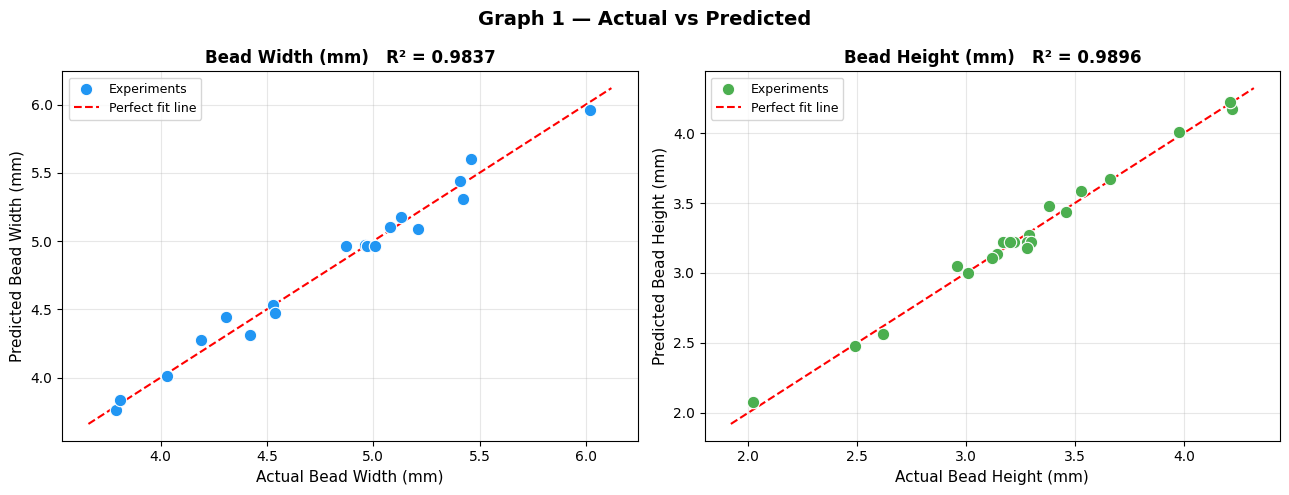

Saved: actual_vs_predicted.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Graph 1 — Actual vs Predicted', fontsize=14, fontweight='bold')

for ax, actual, predicted, label, color, r2 in [
    (axes[0], y_BW, pred_BW, 'Bead Width (mm)',  '#2196F3', r2_bw),
    (axes[1], y_BH, pred_BH, 'Bead Height (mm)', '#4CAF50', r2_bh),
]:
    ax.scatter(actual, predicted, color=color, s=80, edgecolors='white',
               linewidth=0.8, zorder=3, label='Experiments')
    mn = min(actual.min(), predicted.min()) - 0.1
    mx = max(actual.max(), predicted.max()) + 0.1
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit line')
    ax.set_xlabel(f'Actual {label}', fontsize=11)
    ax.set_ylabel(f'Predicted {label}', fontsize=11)
    ax.set_title(f'{label}   R² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")


---
Graph 2: Residual (Error) Plot

**What to look for:**
Errors should be **randomly scattered around 0**.
No pattern = good model. A pattern = the model is missing something.


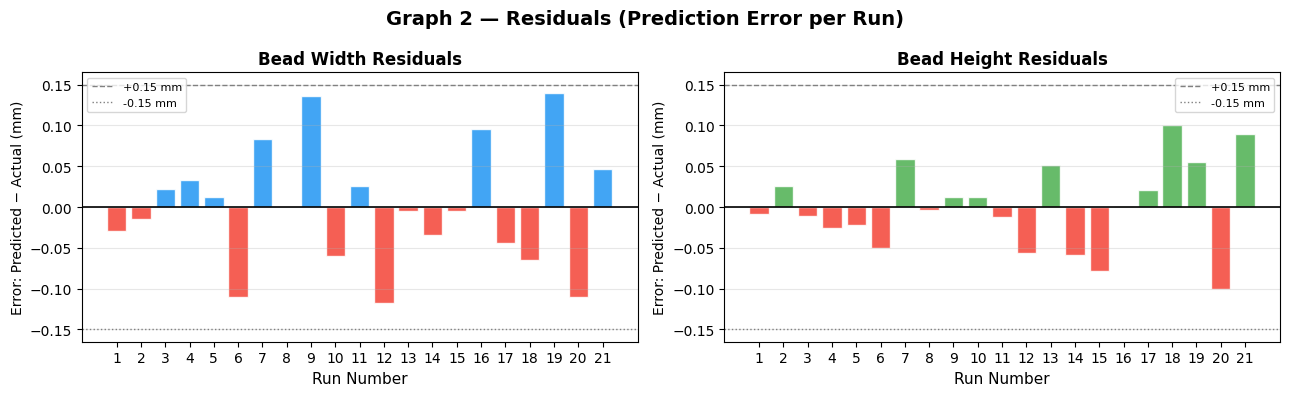

Saved: graph2_residuals.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Graph 2 — Residuals (Prediction Error per Run)', fontsize=14, fontweight='bold')

runs = np.arange(1, n+1)

for ax, actual, predicted, label, color in [
    (axes[0], y_BW, pred_BW, 'Bead Width',  '#2196F3'),
    (axes[1], y_BH, pred_BH, 'Bead Height', '#4CAF50'),
]:
    residuals = predicted - actual
    ax.bar(runs, residuals, color=[color if r >= 0 else '#F44336' for r in residuals],
           edgecolor='white', alpha=0.85)
    ax.axhline(0,     color='black', linewidth=1.2)
    ax.axhline( 0.15, color='gray',  linestyle='--', linewidth=1, label='+0.15 mm')
    ax.axhline(-0.15, color='gray',  linestyle=':',  linewidth=1, label='-0.15 mm')
    ax.set_xlabel('Run Number', fontsize=11)
    ax.set_ylabel('Error: Predicted − Actual (mm)', fontsize=10)
    ax.set_title(f'{label} Residuals', fontweight='bold')
    ax.set_xticks(runs)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph2_residuals.png")


Graph 3: Effect of Each Parameter on BW and BH

**What to look for:**
- **Voltage** has the biggest effect on BW (steep slope)
- **Travel Speed** has the biggest effect on BH
- The **red dashed line** marks the optimal value from the paper
- Other two parameters are held at their optimal values while one varies


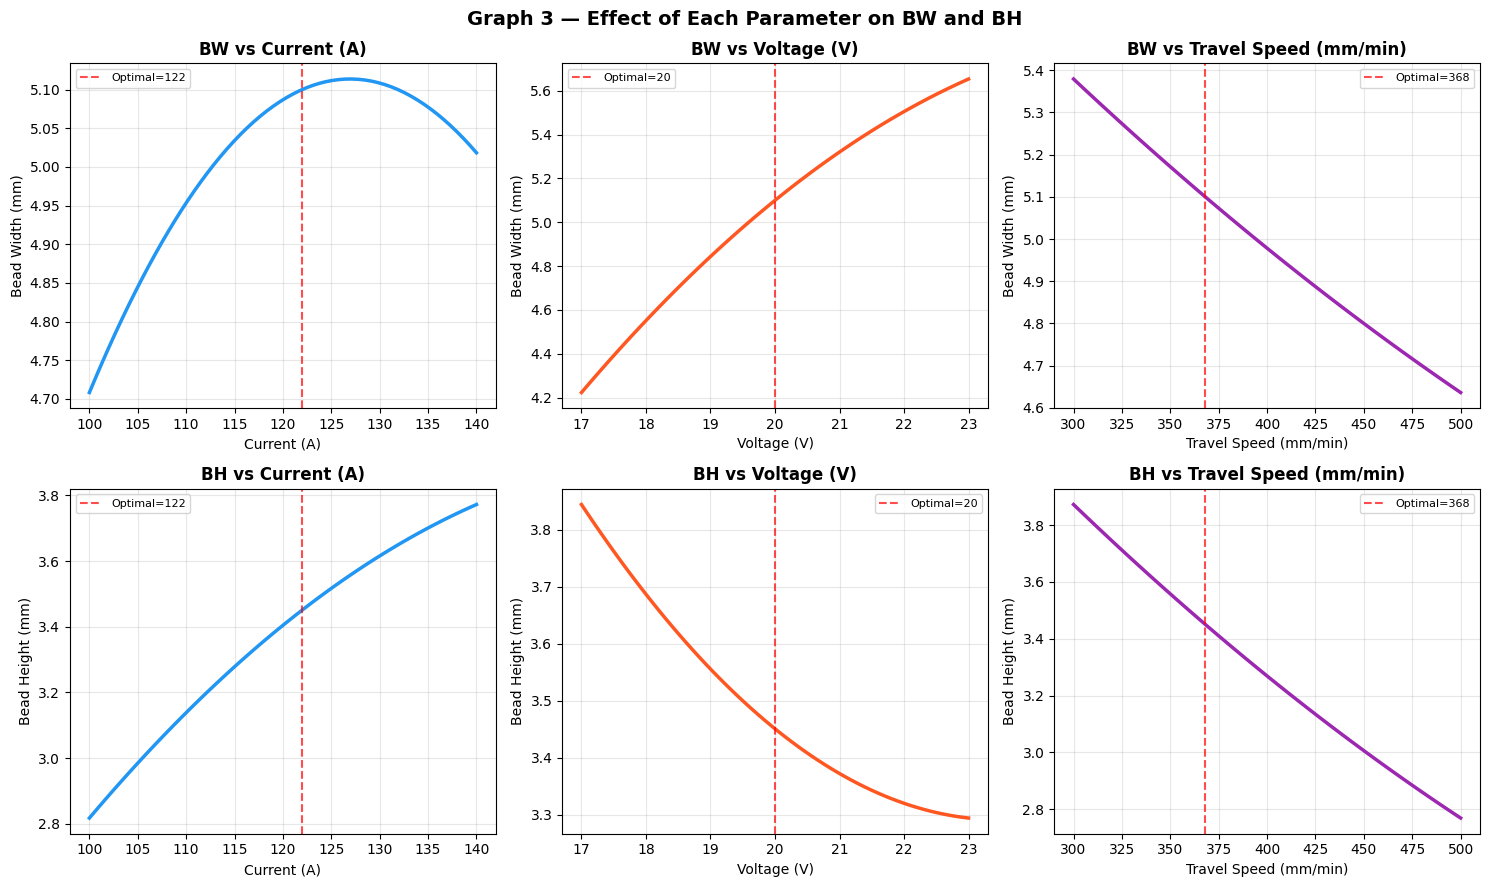

Saved: graph3_parameter_effects.png


In [38]:
# Optimal values from paper
I0, U0, v0 = 122, 20, 368

def predict_array(I, U, v):
    x = np.column_stack([np.ones_like(I), I, U, v,
                         I**2, U**2, v**2, I*U, I*v, U*v])
    return x @ c_BW, x @ c_BH

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Graph 3 — Effect of Each Parameter on BW and BH', fontsize=14, fontweight='bold')

sweeps = [
    ('Current (A)',          np.linspace(100, 140, 60), 'I',  '#2196F3', I0),
    ('Voltage (V)',          np.linspace(17,  23,  60), 'U',  '#FF5722', U0),
    ('Travel Speed (mm/min)',np.linspace(300, 500, 60), 'v',  '#9C27B0', v0),
]

for col, (xlabel, sweep, param, color, opt) in enumerate(sweeps):
    I_s = sweep          if param=='I' else np.full_like(sweep, I0)
    U_s = sweep          if param=='U' else np.full_like(sweep, U0)
    v_s = sweep          if param=='v' else np.full_like(sweep, v0)
    bw_s, bh_s = predict_array(I_s, U_s, v_s)

    # BW — top row
    axes[0][col].plot(sweep, bw_s, color=color, linewidth=2.5)
    axes[0][col].axvline(opt, color='red', linestyle='--', alpha=0.7, label=f'Optimal={opt}')
    axes[0][col].set_xlabel(xlabel, fontsize=10)
    axes[0][col].set_ylabel('Bead Width (mm)', fontsize=10)
    axes[0][col].set_title(f'BW vs {xlabel}', fontweight='bold')
    axes[0][col].legend(fontsize=8); axes[0][col].grid(alpha=0.3)

    # BH — bottom row
    axes[1][col].plot(sweep, bh_s, color=color, linewidth=2.5)
    axes[1][col].axvline(opt, color='red', linestyle='--', alpha=0.7, label=f'Optimal={opt}')
    axes[1][col].set_xlabel(xlabel, fontsize=10)
    axes[1][col].set_ylabel('Bead Height (mm)', fontsize=10)
    axes[1][col].set_title(f'BH vs {xlabel}', fontweight='bold')
    axes[1][col].legend(fontsize=8); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph3_parameter_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph3_parameter_effects.png")


Prediction

In [39]:
def predict_bw_bh(I, U, v):
    if not (100 <= I <= 140): print(f"  WARNING: I={I} outside 100-140 A")
    if not (17  <= U <= 23):  print(f"  WARNING: U={U} outside 17-23 V")
    if not (300 <= v <= 500): print(f"  WARNING: v={v} outside 300-500 mm/min")
    x  = np.array([1, I, U, v, I**2, U**2, v**2, I*U, I*v, U*v])
    BW = round(float(x @ c_BW), 3)
    BH = round(float(x @ c_BH), 3)
    Q  = round((60 * 0.8 * I * U) / v, 2)
    return BW, BH, Q

# ── Change these values ───────────────
I_input = 110    # Current      (A)
U_input = 18    # Voltage      (V)
v_input = 400    # Travel Speed (mm/min)
# ─────────────────────────────────────

BW, BH, Q = predict_bw_bh(I_input, U_input, v_input)

print(f"  Input  →  I = {I_input} A  |  U = {U_input} V  |  v = {v_input} mm/min")
print(f"  {'─'*42}")
print(f"  Bead Width   BW = {BW} mm")
print(f"  Bead Height  BH = {BH} mm")



  Input  →  I = 110 A  |  U = 18 V  |  v = 400 mm/min
  ──────────────────────────────────────────
  Bead Width   BW = 4.309 mm
  Bead Height  BH = 3.18 mm


Testing



In [40]:

my_tests = [
    (100, 20, 300),
    (130, 22, 450),
    (140, 23, 400),
]


labels_test = [f"I={I}\nU={U}\nv={v}" for I, U, v in my_tests]
bw_results, bh_results, = [], [],

print(f"  {'No.':<4} {'I':>5} {'U':>4} {'v':>6}  {'BW (mm)':>8} {'BH (mm)':>8}")
print("  " + "-"*52)
for idx, (I, U, v) in enumerate(my_tests, 1):
    BW, BH, Q = predict_bw_bh(I, U, v)
    bw_results.append(BW)
    bh_results.append(BH)
    print(f"  {idx:<4} {I:>5} {U:>4} {v:>6}  {BW:>8.3f} {BH:>8.3f}")



  No.      I    U      v   BW (mm)  BH (mm)
  ----------------------------------------------------
  1      100   20    300     4.972    3.269
  2      130   22    450     5.177    3.050
  3      140   23    400     5.443    3.434


Upload your new CSV file...


Saving synthetic_my_equation_500.csv to synthetic_my_equation_500 (1).csv

File loaded : synthetic_my_equation_500 (1).csv
Rows        : 500

First 5 rows:
      Current    Voltage  Travel Speed     Width    Height
0  114.981605  21.188970    337.026586  5.374657  3.399307
1  138.028572  20.216578    408.380189  4.991877  3.499010
2  129.279758  18.857166    474.589167  4.433164  3.116951
3  123.946339  21.882770    446.444977  5.152019  2.917553
4  106.240746  21.108387    461.312230  4.795806  2.420689

  PREDICTIONS
   Current   Voltage  Travel Speed    Width   Height  BW_predicted  BH_predicted
114.981605 21.188970    337.026586 5.374657 3.399307         5.418         3.379
138.028572 20.216578    408.380189 4.991877 3.499010         4.936         3.510
129.279758 18.857166    474.589167 4.433164 3.116951         4.448         3.176
123.946339 21.882770    446.444977 5.152019 2.917553         5.174         2.944
106.240746 21.108387    461.312230 4.795806 2.420689         4.764    

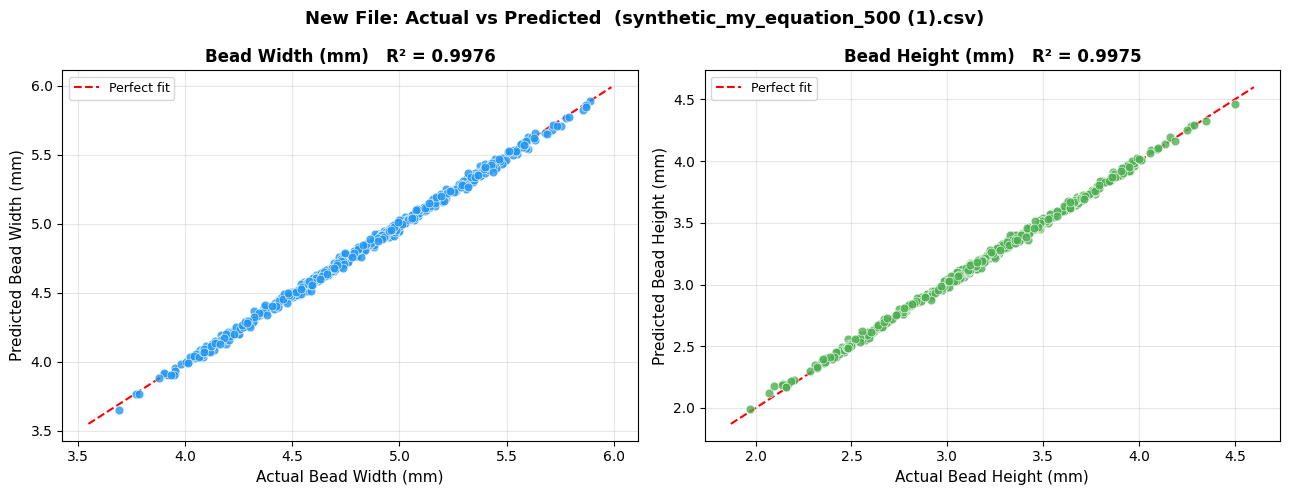

Graph saved: new_file_actual_vs_predicted.png

Results saved: synthetic_my_equation_500 (1)_with_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:

#  TEST A NEW CSV FILE AGAINST THE FITTED EQUATIONS


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── STEP 1: Upload your new CSV file ────────────────────────────
print("Upload your new CSV file...")
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df_new = pd.read_csv(filename)

print(f"\nFile loaded : {filename}")
print(f"Rows        : {len(df_new)}")
print(f"\nFirst 5 rows:")
print(df_new.head())

# ── STEP 2: Extract inputs ───────────────────────────────────────
# Adjust column names below if your file uses different names
I_new = df_new['Current'].values
U_new = df_new['Voltage'].values
v_new = df_new['Travel Speed'].values

# ── STEP 3: Build feature matrix ────────────────────────────────
n_new = len(df_new)

X_new = np.column_stack([
    np.ones(n_new),
    I_new, U_new, v_new,
    I_new**2, U_new**2, v_new**2,
    I_new * U_new,
    I_new * v_new,
    U_new * v_new,
])

# ── STEP 4: Predict BW and BH ────────────────────────────────────
pred_BW = np.round(X_new @ c_BW, 3)
pred_BH = np.round(X_new @ c_BH, 3)

# ── STEP 5: Add predictions to the dataframe ────────────────────
df_new['BW_predicted'] = pred_BW
df_new['BH_predicted'] = pred_BH


print("\n" + "="*65)
print("  PREDICTIONS")
print("="*65)
print(df_new.to_string(index=False))

# ── STEP 6: If actual BW and BH exist, calculate errors ─────────
has_actual = 'Width' in df_new.columns and 'Height' in df_new.columns

if has_actual:
    actual_BW = df_new['Width'].values
    actual_BH = df_new['Height'].values

    bw_err = pred_BW - actual_BW
    bh_err = pred_BH - actual_BH

    df_new['BW_error'] = np.round(bw_err, 3)
    df_new['BH_error'] = np.round(bh_err, 3)
    df_new['BW_err%']  = np.round(bw_err / actual_BW * 100, 2)
    df_new['BH_err%']  = np.round(bh_err / actual_BH * 100, 2)

    mae_bw = np.mean(np.abs(bw_err))
    mae_bh = np.mean(np.abs(bh_err))
    max_bw = np.max(np.abs(bw_err))
    max_bh = np.max(np.abs(bh_err))

    print("\n" + "="*65)
    print("  ERROR SUMMARY (Predicted vs Actual)")
    print("="*65)
    print(f"  Mean absolute error  →  BW: {mae_bw:.4f} mm   BH: {mae_bh:.4f} mm")
    print(f"  Max  absolute error  →  BW: {max_bw:.4f} mm   BH: {max_bh:.4f} mm")

    # ── STEP 7: Actual vs Predicted plot ────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'New File: Actual vs Predicted  ({filename})',
                 fontsize=13, fontweight='bold')

    for ax, actual, predicted, label, color in [
        (axes[0], actual_BW, pred_BW, 'Bead Width (mm)',  '#2196F3'),
        (axes[1], actual_BH, pred_BH, 'Bead Height (mm)', '#4CAF50'),
    ]:
        ax.scatter(actual, predicted, color=color, s=40,
                   edgecolors='white', linewidth=0.5, alpha=0.8, zorder=3)
        mn = min(actual.min(), predicted.min()) - 0.1
        mx = max(actual.max(), predicted.max()) + 0.1
        ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')

        # R² for new file
        ss_res = np.sum((actual - predicted)**2)
        ss_tot = np.sum((actual - actual.mean())**2)
        r2 = 1 - ss_res/ss_tot

        ax.set_xlabel(f'Actual {label}', fontsize=11)
        ax.set_ylabel(f'Predicted {label}', fontsize=11)
        ax.set_title(f'{label}   R² = {r2:.4f}', fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('new_file_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graph saved: new_file_actual_vs_predicted.png")

else:
    # No actual values — just plot the predictions
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'New File: Predictions  ({filename})',
                 fontsize=13, fontweight='bold')

    axes[0].scatter(range(n_new), pred_BW, color='#2196F3',
                    s=40, edgecolors='white', linewidth=0.5)
    axes[0].axhline(pred_BW.mean(), color='red', linestyle='--',
                    label=f'Mean = {pred_BW.mean():.3f} mm')
    axes[0].set_xlabel('Row number')
    axes[0].set_ylabel('Predicted BW (mm)')
    axes[0].set_title('Predicted Bead Width', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].scatter(range(n_new), pred_BH, color='#4CAF50',
                    s=40, edgecolors='white', linewidth=0.5)
    axes[1].axhline(pred_BH.mean(), color='red', linestyle='--',
                    label=f'Mean = {pred_BH.mean():.3f} mm')
    axes[1].set_xlabel('Row number')
    axes[1].set_ylabel('Predicted BH (mm)')
    axes[1].set_title('Predicted Bead Height', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('new_file_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graph saved: new_file_predictions.png")

# ── STEP 8: Save results to CSV ─────────────────────────────────
output_name = filename.replace('.csv', '_with_predictions.csv')
df_new.to_csv(output_name, index=False)
print(f"\nResults saved: {output_name}")

# Download the results file
files.download(output_name)

Research Paper

Upload your CSV file...


Saving synthetic_paper_equation_500.csv to synthetic_paper_equation_500 (1).csv

File loaded: synthetic_paper_equation_500 (1).csv
Rows: 500
      Current    Voltage  Travel Speed     Width    Height
0  114.981605  21.188970    337.026586  5.389297  3.318239
1  138.028572  20.216578    408.380189  4.989842  3.386329
2  129.279758  18.857166    474.589167  4.404965  2.970309
3  123.946339  21.882770    446.444977  5.165626  2.814888
4  106.240746  21.108387    461.312230  4.792436  2.292835

Predictions:
   Current   Voltage  Travel Speed    Width   Height  BW_predicted  BH_predicted  Q_predicted
114.981605 21.188970    337.026586 5.389297 3.318239         5.439         3.292       346.99
138.028572 20.216578    408.380189 4.989842 3.386329         4.944         3.389       327.98
129.279758 18.857166    474.589167 4.404965 2.970309         4.433         3.013       246.56
123.946339 21.882770    446.444977 5.165626 2.814888         5.199         2.827       291.61
106.240746 21.108387 

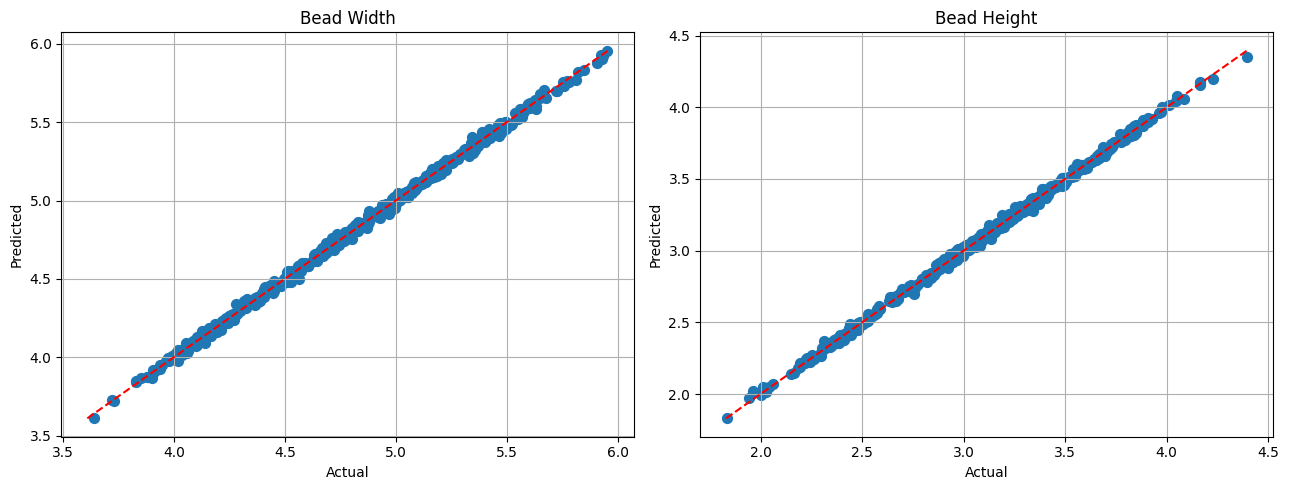


Results saved: synthetic_paper_equation_500 (1)_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# Upload CSV file
# ==============================
print("Upload your CSV file...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\nFile loaded: {filename}")
print(f"Rows: {len(df)}")
print(df.head())

# ==============================
# Read input columns
# ==============================
I = df['Current'].values
U = df['Voltage'].values
v = df['Travel Speed'].values

# ==============================
# Published RSM Equations
# ==============================

# Bead Width (BW)
pred_BW = (
    -16.190
    + 0.143 * I
    + 1.027 * U
    + 0.000508 * v
    + 0.000375 * I * U
    - 0.000016 * I * v
    - 0.000263 * U * v      # Verify this coefficient from your paper
    - 0.000567 * I**2
    - 0.018 * U**2
    + 0.00000367 * v**2
)

# Bead Height (BH)
pred_BH = (
    7.575
    + 0.085 * I
    - 0.623 * U
    - 0.014 * v
    + 0.00000833 * I * U
    + 0.000024 * I * v
    + 0.000048 * U * v
    - 0.000292 * I**2
    + 0.013 * U**2
    + 0.000005223 * v**2
)

# Heat input (optional)
pred_Q = (60 * 0.8 * I * U) / v

# ==============================
# Add predictions
# ==============================
df['BW_predicted'] = np.round(pred_BW, 3)
df['BH_predicted'] = np.round(pred_BH, 3)
df['Q_predicted'] = np.round(pred_Q, 2)

print("\nPredictions:")
print(df.to_string(index=False))

# ==============================
# Compare with actual values
# ==============================
if 'Width' in df.columns and 'Height' in df.columns:

    actual_BW = df['Width'].values
    actual_BH = df['Height'].values

    bw_error = pred_BW - actual_BW
    bh_error = pred_BH - actual_BH

    df['BW_error'] = np.round(bw_error, 3)
    df['BH_error'] = np.round(bh_error, 3)
    df['BW_error_%'] = np.round(bw_error / actual_BW * 100, 2)
    df['BH_error_%'] = np.round(bh_error / actual_BH * 100, 2)

    # Metrics
    mae_bw = np.mean(np.abs(bw_error))
    mae_bh = np.mean(np.abs(bh_error))

    rmse_bw = np.sqrt(np.mean(bw_error**2))
    rmse_bh = np.sqrt(np.mean(bh_error**2))

    ss_res_bw = np.sum((actual_BW - pred_BW)**2)
    ss_tot_bw = np.sum((actual_BW - actual_BW.mean())**2)
    r2_bw = 1 - ss_res_bw / ss_tot_bw

    ss_res_bh = np.sum((actual_BH - pred_BH)**2)
    ss_tot_bh = np.sum((actual_BH - actual_BH.mean())**2)
    r2_bh = 1 - ss_res_bh / ss_tot_bh

    print("\n========== MODEL PERFORMANCE ==========")
    print(f"BW : MAE = {mae_bw:.4f} mm")
    print(f"BW : RMSE = {rmse_bw:.4f} mm")
    print(f"BW : R² = {r2_bw:.4f}")

    print(f"BH : MAE = {mae_bh:.4f} mm")
    print(f"BH : RMSE = {rmse_bh:.4f} mm")
    print(f"BH : R² = {r2_bh:.4f}")

    # Actual vs Predicted plots
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, actual, predicted, title in [
        (axes[0], actual_BW, pred_BW, 'Bead Width'),
        (axes[1], actual_BH, pred_BH, 'Bead Height')
    ]:

        ax.scatter(actual, predicted, s=50)
        mn = min(actual.min(), predicted.min())
        mx = max(actual.max(), predicted.max())
        ax.plot([mn, mx], [mn, mx], 'r--')

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(title)
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# ==============================
# Save results
# ==============================
output_file = filename.replace('.csv', '_predictions.csv')
df.to_csv(output_file, index=False)

print(f"\nResults saved: {output_file}")
files.download(output_file)